In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [41]:
cancer = load_breast_cancer()

# Use only two features for visualization
X = pd.DataFrame(
    cancer.data[:, :2],
    columns=cancer.feature_names[:2]
)

y = cancer.target

In [42]:
print(cancer.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [43]:
print(cancer.data.shape)

(569, 30)


In [44]:
cancer.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
linear_model = SVC(kernel='linear', random_state=42)

In [48]:
linear_model.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [49]:
linear_pred = linear_model.predict(X_test_scaled)

In [50]:
print("Accuracy:",
      accuracy_score(y_test, linear_pred))

Accuracy: 0.9035087719298246


In [51]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, linear_pred))


Confusion Matrix
[[36  7]
 [ 4 67]]


In [52]:
print("\nClassification Report")
print(classification_report(
    y_test,
    linear_pred,
    target_names=cancer.target_names
))


Classification Report
              precision    recall  f1-score   support

   malignant       0.90      0.84      0.87        43
      benign       0.91      0.94      0.92        71

    accuracy                           0.90       114
   macro avg       0.90      0.89      0.90       114
weighted avg       0.90      0.90      0.90       114



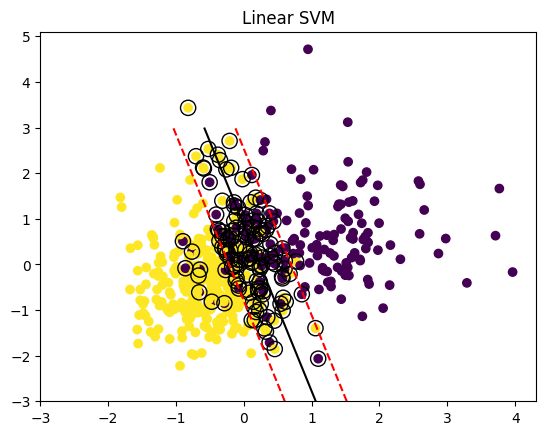

In [58]:

xx, yy = np.meshgrid(
    np.linspace(-3, 3, 100),
    np.linspace(-3, 3, 100)
)


Z = linear_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.scatter(
    X_train_scaled[:,0],
    X_train_scaled[:,1],
    c=y_train
)

# Plot hyperplane and margins
plt.contour(
    xx,
    yy,
    Z,
    levels=[-1, 0, 1],
    colors=['red', 'black', 'red'],
    linestyles=['--', '-', '--']
)


plt.scatter(
    linear_model.support_vectors_[:,0],
    linear_model.support_vectors_[:,1],
    s=120,
    facecolors='none',
    edgecolors='black'
)

plt.title("Linear SVM")
plt.show()